In [ ]:
# %%
# flow matching
# xt =(1-t)x0 + tx1
# v = dx/dt = x1 - x0
# Training:  arg min  E[‖X1 − X0 − v(tX1 + (1 − t)X0, t)‖2]  , with t ∼ Uniform([0, 1]).
# loss = |v_theta(xt, t) - (x1-x0)|^2 感觉真实分布很难学，不如高斯分布简单
# sampling ODE dx/dt = v @ (t=0, x0)
# xn+1 = xt + v*dt t=[0, 1] # 推理步骤变少了，20步即可生成

# %%
# Basic Math
print("hello, this is notebook")

hello, this is notebook


In [2]:
# %%
#%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_s_curve, make_moons, make_circles
import torch
from torch import nn
from torch.optim import AdamW, Adam
from torch.utils.data import DataLoader, TensorDataset


moon_curve shape: (10000, 2)
circle shape: (10000, 2)
s-curve shape: (10000, 2)


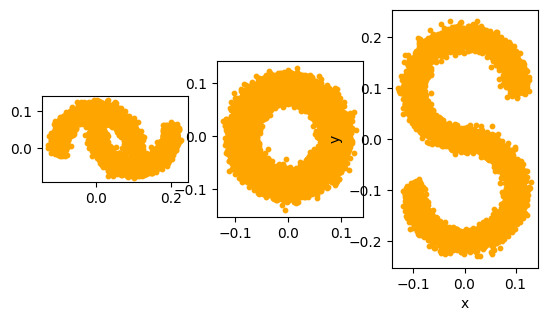

S曲线是若干离散点组成，看作是一种数据分布


In [10]:
# %%
data={}
m_curve, y = make_moons(10000, noise=0.1)
m_curve = m_curve/10.0
data["moon"] = torch.from_numpy(m_curve).float()
print("moon_curve shape:", m_curve.shape)

c_curve, y = make_circles(10000, noise=0.1)
c_curve = c_curve/10.0
data["circle"] = torch.from_numpy(c_curve).float()
print("circle shape:", c_curve.shape)

s_curve, _ = make_s_curve(10000, noise=0.1)
s_curve = s_curve[:, [0, 2]]/10.0 # 只保留x和z坐标，并缩放到0-1范围内
data["scurve"] = torch.from_numpy(s_curve).float()
print("s-curve shape:",s_curve.shape)

fig, axs = plt.subplots(1, len(data))
for i, (l, d) in enumerate(data.items()):
    axs[i].scatter(d[:, 0], d[:, 1], s=10, color="orange", label=l)
    axs[i].set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.show()
print("S曲线是若干离散点组成，看作是一种数据分布")

# %%

In [25]:
# 1.搭建噪声学习网络epsilon_theta
# 2. 数据学习训练 
#    loss = E[||epsilon - epsilon_theta(x_t, t)||^2]

# 可以选择2种网络架构
# （1）UNet 结构的噪声预测网络
# （2）Transformer 结构的噪声预测网络
class VelocityPredictorNet(nn.Module):
    # 此处仅为演示使用简单net结构 MLP
    def __init__(self, num_units:int=128):
        super(VelocityPredictorNet, self).__init__()

        # 时间步嵌入层
        #self.embeding = nn.Embedding(num_steps, num_units)
        # 适用于浮点数
        self.embeding = nn.Sequential(
            nn.Linear(1, num_units),
            nn.SiLU(),
            nn.Linear(num_units, num_units)
        )

        # 线性层网络, 串联
        # xt 图片 + time embding + 空
        self.linear = nn.Sequential(
                nn.Linear(2+num_units, num_units),
                nn.SiLU(),
                nn.Linear(num_units, num_units),
                nn.SiLU(),
                nn.Linear(num_units, num_units),
                nn.SiLU(),
                nn.Linear(num_units, 2)
        )

    def forward(self, xt:torch.Tensor, t:torch.Tensor) -> torch.Tensor:
        """
        xt: shape (nt, npts, dim=2)
        t: shape (nt, 1)
        返回 epsilon_theta(xt, t)，shape (nt, npts, dim=2)
        """
        
        t_embeding = self.embeding(t) # 时间步嵌入，shape (nt, num_units)
        nt, npts, dim = xt.shape
        t_embeding = t_embeding.unsqueeze(1).expand(-1, npts, -1) # (nt, ntps, num_units)
        # 拼接时间步嵌入和输入
        xt_cat =  torch.cat([xt, t_embeding], dim=-1) # shape (nt, npts, 2 + num_units)
        
        #最后一层线性层输出噪声预测 velocity_theta
        velocity_theta = self.linear(xt_cat) # 线性层 (npts, 2)
        return velocity_theta
    

class VelocityPredictorNetCond(nn.Module):
    """ 条件 """
    # 此处仅为演示使用简单net结构 MLP
    def __init__(self, num_units:int=128):
        super(VelocityPredictorNetCond, self).__init__()

        # 时间步嵌入层
        #self.embeding = nn.Embedding(num_steps, num_units)
        # 适用于浮点数
        self.embeding = nn.Sequential(
            nn.Linear(1, num_units),
            nn.SiLU(),
            nn.Linear(num_units, num_units)
        )

        # 条件嵌入层
        # 输入维度为1
        self.condition = nn.Sequential(
            nn.Linear(1, num_units),
            nn.SiLU(),
            nn.Linear(num_units, num_units)
        )

        # 线性层网络, 串联
        # xt 图片 + time embding + 条件
        self.linear = nn.Sequential(
                nn.Linear(2+num_units+num_units, 2*num_units),
                nn.SiLU(),
                nn.Linear(2*num_units, 2*num_units),
                nn.SiLU(),
                nn.Linear(2*num_units, 2*num_units),
                nn.SiLU(),
                nn.Linear(2*num_units, 2)
        )

    def forward(self, xt:torch.Tensor, t:torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        """
        xt: shape (nt, npts, dim=2)
        t: shape (nt, 1)
        cond: shape(1, 1)
        返回 epsilon_theta(xt, t, c)，shape (nt, npts, dim=2)
        """
        
        t_embeding = self.embeding(t) # 时间步嵌入，shape (nt, num_units)
        nt, npts, dim = xt.shape
        t_embeding = t_embeding.unsqueeze(1).expand(-1, npts, -1) # (nt, ntps, num_units)
        # 条件
        c_embeding = self.condition(cond).unsqueeze(0) # (1, 1, num_units)
        c_embeding = c_embeding.expand(nt, npts, -1)
        # 拼接时间步嵌入和输入
        xt_cat =  torch.cat([xt, t_embeding, c_embeding], dim=-1) # shape (nt, npts, 2 + num_units + num_units)
        
        #最后一层线性层输出噪声预测 velocity_theta
        velocity_theta = self.linear(xt_cat) # 线性层 (nt, npts, 2)
        return velocity_theta

 epoch 0/1000 mean loss:(0.9045160412788391, 0.8944206237792969)
 epoch 0/1000 mean loss:(1.0792152881622314, 0.9636212587356567)
 epoch 0/1000 mean loss:(0.9759362936019897, 0.5972355604171753)
 epoch 20/1000 mean loss:(0.045384831726551056, 0.042081285268068314)
 epoch 20/1000 mean loss:(0.05473368242383003, 0.05155233293771744)
 epoch 20/1000 mean loss:(0.1001657024025917, 0.09228663146495819)
 epoch 40/1000 mean loss:(0.13630935549736023, 0.13266605138778687)
 epoch 40/1000 mean loss:(0.12424423545598984, 0.11783929914236069)
 epoch 40/1000 mean loss:(0.20319700241088867, 0.20166246592998505)
 epoch 60/1000 mean loss:(0.03252854943275452, 0.03205915540456772)
 epoch 60/1000 mean loss:(0.08387818187475204, 0.0829896405339241)
 epoch 60/1000 mean loss:(0.18305079638957977, 0.18564152717590332)
 epoch 80/1000 mean loss:(0.13502237200737, 0.13440407812595367)
 epoch 80/1000 mean loss:(0.1640632152557373, 0.16317272186279297)
 epoch 80/1000 mean loss:(0.1637122482061386, 0.1662842482328

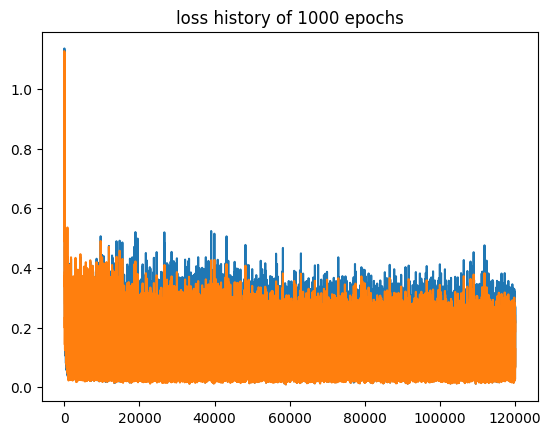

In [31]:
# 配对数据 X0 --- X1
# 随机t=[0,1] 然后 预测 V（Xt = tX1 + (1-t)X0, t）
# loss = v -|x1-x0|
model = VelocityPredictorNet()
model_cond = VelocityPredictorNetCond()
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
optimizer_cond = AdamW(model_cond.parameters(), lr=1e-4, weight_decay=1e-4)

## 非常重要epoch内循环
# 保证每个epoch都能看到所有数据，且每个batch随机抽取不同时间步t
epochs = 1000
sample_npts = 256
nt = 20
dict_cond = {"moon": torch.tensor([[0.0]]), 
             "circle": torch.tensor([[1.0]]),
             "scurve": torch.tensor([[2.0]])}
## total_ns = 10000//256 = 40
history = []
for epoch in range(epochs):
    # 训练过程中每个epoch都要遍历整个数据集
    for cond, mat in data.items():
        c = dict_cond[cond]
        perm = torch.randperm(mat.shape[0])
        for start in range(0, perm.shape[0], sample_npts):
            # x1图像数据
            x1 = mat[start:start+sample_npts] # shape (npts, dim)
            x0 = torch.randn_like(x1) # 随机
            # volocity = x1 - x0
            velocity_true = x1 - x0
            t = torch.rand(nt).unsqueeze(-1) #(nt, 1)
            x1 = x1.unsqueeze(0) # (1, npts, dim)
            x0 = x0.unsqueeze(0) # (1, npts, dim)
            text = t.unsqueeze(-1)  #(nt, 1, 1)
            xt = text*x1 + (1.0- text)*x0 # (nt, npts, dim)
            
            velocity_pred = model(xt, t) # (nt, ntps, dim)
            velocity_pred_c = model_cond(xt, t, c) # (nt, npts, dim)
            loss = torch.square((velocity_pred - velocity_true)).mean()
            loss_cond = torch.square((velocity_pred_c - velocity_true)).mean()
            #
            model.zero_grad()
            model_cond.zero_grad()
            loss.backward()
            loss_cond.backward()
            optimizer.step()
            optimizer_cond.step()

            history.append((loss.item(), loss_cond.item()))
        if epoch % 20 == 0:
            print(f" epoch {epoch}/{epochs} mean loss:{history[-1]}")
#

torch.save(model.state_dict(), "flow_state_dict.pt")
plt.plot([l0 for l0, l1 in history])
plt.plot([l1 for l0, l1 in history])
plt.title(f"loss history of {epochs} epochs")
plt.show()

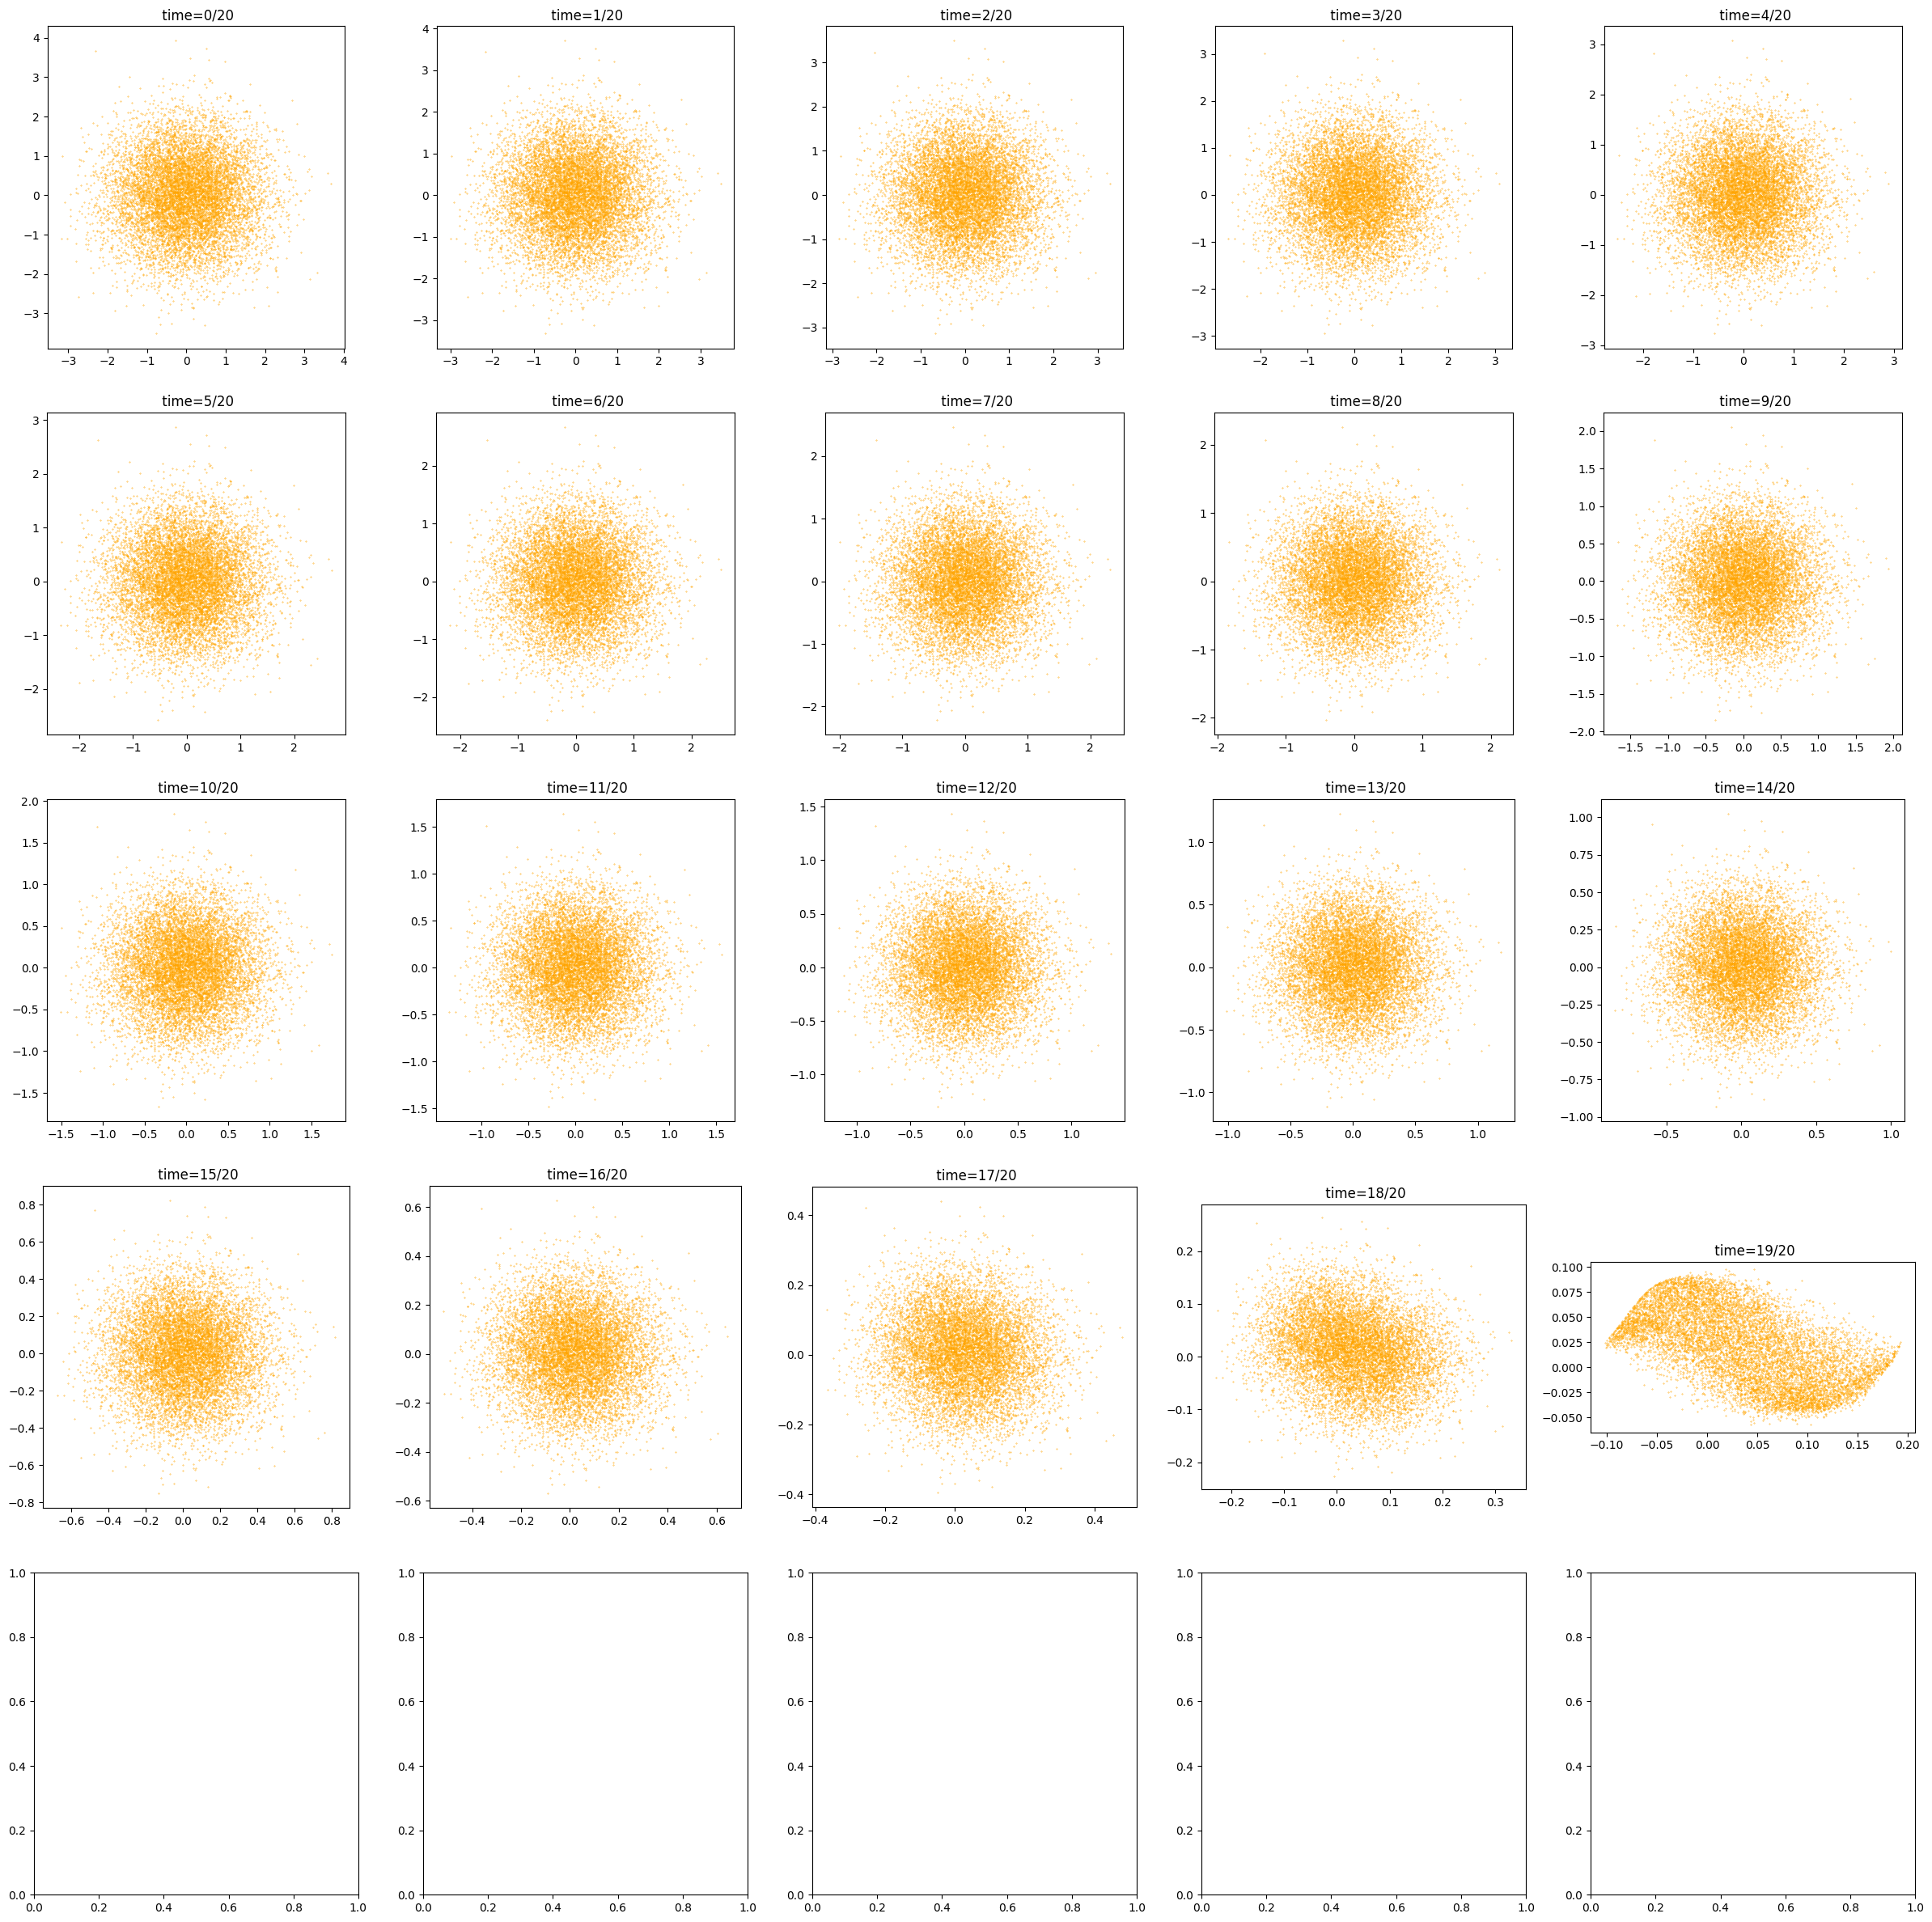

In [ ]:
# sampling 
# xt = x_t-1 + v*dt
# condtioned vel(xt, t, c)

# eular time scheme
model.eval()
cond_name = "circle" #"scurve" "moon"
cfg_weight = 0.9 
cond = dict_cond[cond_name]
data_cond = data[cond_name]
with torch.no_grad():
    steps = 20
    t = 0.0
    dt = 1.0/steps
    xt = torch.randn(data_cond.shape[0], 2).unsqueeze(0) # t = 0 (1, npts, dim)
    frames = []
    for i in range(steps):
        ttensor = torch.tensor([[t]]) # (1, 1)
        volcity = model(xt, ttensor) # (1, npts, dim)
        volcity_cond = model_cond(xt, ttensor, cond) # (1, npts, dim)
        volcity_merge = volcity_cond - volcity
        xt = xt + (volcity + cfg_weight*(volcity_merge))*torch.tensor([[[dt]]])
        t += dt

        npdata = xt[0].clone().detach().numpy()
        frames.append((npdata, i))

    fig, ax = plt.subplots(len(frames)//5+1, 5, figsize=(30, 30))
    for i, (xt, ti) in enumerate(frames):
        idx = i // 5
        idj = i - idx*5
        ax[idx, idj].scatter(xt[:, 0], xt[:, 1],
                    s=0.1, color="orange")
        ax[idx, idj].set_title(f" time={ti}/{steps}")
        ax[idx, idj].set_aspect('equal')
    plt.show()